# 08_polynomial_regression

## Goal

Understand how polynomial regression can fit curves using linear regression.

선형 회귀(linear regression)를 이용해 곡선 데이터를 학습하는  
polynomial regression의 개념을 이해한다.

We will create polynomial features such as x, x², and x³.

x, x², x³ 같은 새로운 feature를 만들어 곡선을 모델링하는 방법을 실습한다.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# numpy 출력 옵션
np.set_printoptions(precision=3, suppress=True)

## 1. Create a Non-linear Dataset

We create a simple dataset that follows a curved pattern.

곡선 형태의 간단한 데이터셋을 생성한다.

A straight line will not fit this data well,
so polynomial features will help the model fit the curve.

직선 모델로는 이 데이터를 잘 설명하기 어렵기 때문에
polynomial feature를 사용하면 더 잘 맞출 수 있다.

In [2]:
# 간단한 비선형 데이터 생성
# y = 1 + x^2 형태를 따라가는 예제
x_train = np.arange(0, 20, 1, dtype=float)
y_train = 1 + x_train**2

print("x_train:", x_train)
print("y_train:", y_train)

x_train: [ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.
 18. 19.]
y_train: [  1.   2.   5.  10.  17.  26.  37.  50.  65.  82. 101. 122. 145. 170.
 197. 226. 257. 290. 325. 362.]


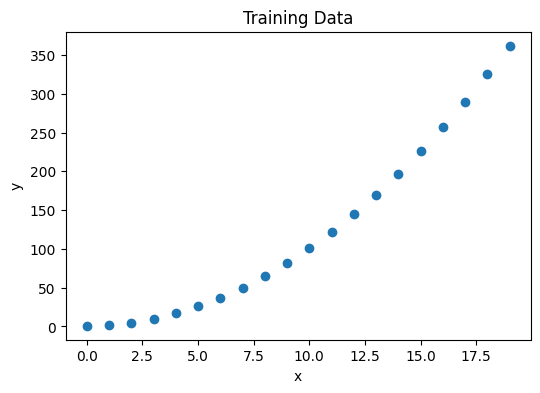

In [4]:
plt.figure(figsize=(6, 4))
plt.scatter(x_train, y_train)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Training Data")
plt.show()

## 2. Linear Regression Functions

Even though we want to fit a curve,
we still use linear regression.

곡선을 맞추려고 하지만
여전히 linear regression 알고리즘을 사용한다.

The key idea is to create new features.

핵심 아이디어는 새로운 feature를 만드는 것이다.

In [5]:
def compute_cost(X, y, w, b):
    m = X.shape[0]

    # 모든 데이터의 예측값 계산
    preds = X @ w + b
    cost = (1 / (2 * m)) * np.sum((preds - y) ** 2)
    return cost

def compute_gradient(X, y, w, b):
    m, n = X.shape
    dj_dw = np.zeros(n)
    dj_db = 0.0

    for i in range(m):
        # 현재 데이터 i의 예측 오차
        error = (X[i] @ w + b) - y[i]

        # 각 wigth에 대한 gradient 누적
        dj_dw += error * X[i]
        dj_db += error

    # 평균 gradient
    dj_dw /= m
    dj_db /= m

    return dj_dw, dj_db

def gradient_descent(X, y, w, b, alpha, iterations):
    cost_history = []

    for it in range(iterations):
        dj_dw, dj_db = compute_gradient(X, y, w, b)

        w = w - alpha * dj_dw
        b = b - alpha * dj_db

        # 현재 cost 저장
        cost_history.append(compute_cost(X, y, w, b))

    return w, b, np.array(cost_history)

## 3. Linear Regression with Feature x

First, we train a model using only one feature: x.

먼저 feature 하나(x)만 사용해서 모델을 학습한다.

This means the model can only fit a straight line.

이 경우 모델은 직선만 학습할 수 있다.

In [9]:
# x 하나만 feature로 사용
X_linear = x_train.reshape(-1, 1)

print("X_linear shape:", X_linear)
print(X_linear[:5])


X_linear shape: [[ 0.]
 [ 1.]
 [ 2.]
 [ 3.]
 [ 4.]
 [ 5.]
 [ 6.]
 [ 7.]
 [ 8.]
 [ 9.]
 [10.]
 [11.]
 [12.]
 [13.]
 [14.]
 [15.]
 [16.]
 [17.]
 [18.]
 [19.]]
[[0.]
 [1.]
 [2.]
 [3.]
 [4.]]


In [11]:
# 초기값
w_init = np.zeros(X_linear.shape[1])
b_init = 0.0

# 학습
w_lin, b_lin, J_lin = gradient_descent(
    X_linear, y_train,
    w_init, b_init,
    alpha=1e-3,
    iterations=10000
)

print("Linear Regression")
print("w:", w_lin)
print("b:", b_lin)
print("final cost:", J_lin[-1])

Linear Regression
w: [18.697]
b: -52.070739885064775
final cost: 440.97836498169227


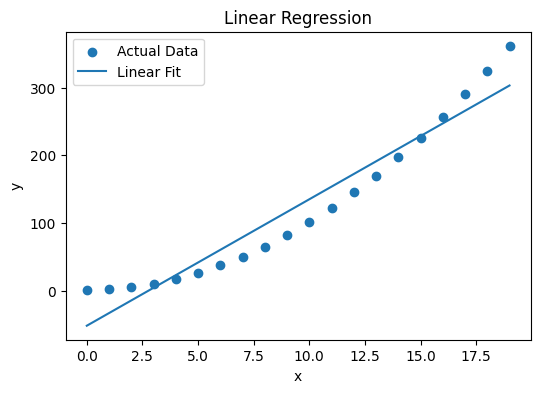

In [12]:
# 예측값 계산
y_pred_lin = X_linear @ w_lin + b_lin

plt.figure(figsize=(6, 4))
plt.scatter(x_train, y_train, label="Actual Data")
plt.plot(x_train, y_pred_lin, label="Linear Fit")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Linear Regression")
plt.legend()
plt.show()

## 4. Polynomial Features

Polynomial regression works by creating new features
such as x² and x³.

Polynomial regression은 x², x³ 같은
새로운 feature를 만들어 사용하는 방법이다.

Example features:
- x
- x²
- x³

이렇게 새로운 feature를 추가하면
모델이 곡선을 학습할 수 있다.

In [ ]:
# polynomial features 생성
# 각 데이터에 대해 [x, x^2, x^3] 형태로 만든다.
# 열(column) 방향으로 붙이기
X_poly = np.c_[x_train, x_train**2, x_train**3]

print("X_poly shape:", X_poly.shape)
print(X_poly[:5])

X_poly shape: (20, 3)
[[ 0.  0.  0.]
 [ 1.  1.  1.]
 [ 2.  4.  8.]
 [ 3.  9. 27.]
 [ 4. 16. 64.]]


## 5. Why Feature Scaling Matters

Polynomial features can grow very large.

Polynomial feature는 값의 범위가 매우 커질 수 있다.

Example:
- x = 10
- x² = 100
- x³ = 1000

Because of this, feature scaling becomes very important.

따라서 polynomial regression에서는
feature scaling이 매우 중요하다.

In [27]:
def zscore_normalization(X, eps=1e-12):
    # x_scaled = (x - mean) / std
    mu = np.mean(X, axis=0)
    # 표준 편차
    sigma = np.std(X, axis=0)

    # 표준편차가 0일 경우 division 오류 방지
    # np.where(조건, Ture일때값, False일때값)
    sigma = np.where(sigma < eps, 1.0, sigma)

    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

In [18]:
# polynomial feature scaling
X_poly_scaled, mu_poly, sigma_poly = zscore_normalization(X_poly)

print("mu:", mu_poly)
print("sigma:", sigma_poly)
print("X_poly_scaled[:5]", X_poly_scaled[:5])

mu: [   9.5  123.5 1805. ]
sigma: [   5.766  113.495 2089.202]
X_poly_scaled[:5] [[-1.648 -1.088 -0.864]
 [-1.474 -1.079 -0.863]
 [-1.301 -1.053 -0.86 ]
 [-1.127 -1.009 -0.851]
 [-0.954 -0.947 -0.833]]


## 6. Train Polynomial Regression

Now we train linear regression using polynomial features.

이제 polynomial feature를 사용해
linear regression을 학습한다.

Even though the model is still linear in the weights,
it can now fit a curve.

모델은 여전히 가중치에 대해 선형이지만
곡선을 학습할 수 있게 된다.

In [19]:
w_init = np.zeros(X_poly_scaled.shape[1])
b_init = 0.0

w_poly, b_poly, J_poly = gradient_descent(
    X_poly_scaled, y_train,
    w_init, b_init,
    alpha=1e-1,
    iterations=5000
)

print("Polynomial Regression")
print("w:", w_poly)
print("b:", b_poly)
print("final cost:", J_poly[-1])

Polynomial Regression
w: [14.856 75.652 23.789]
b: 124.49999999999994
final cost: 1.465383815622503


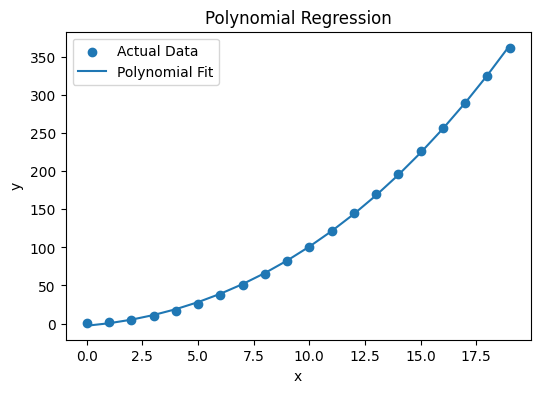

In [23]:
# 예측값 계산
y_pred_poly = X_poly_scaled @ w_poly + b_poly

plt.figure(figsize=(6,4))
plt.scatter(x_train, y_train, label="Actual Data")
plt.plot(x_train, y_pred_poly, label="Polynomial Fit")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Polynomial Regression")
plt.legend()
plt.show()

## 7. Compare Linear vs Polynomial Regression

We compare the predictions of linear regression
and polynomial regression.

linear regression과 polynomial regression의
예측 결과를 비교한다.

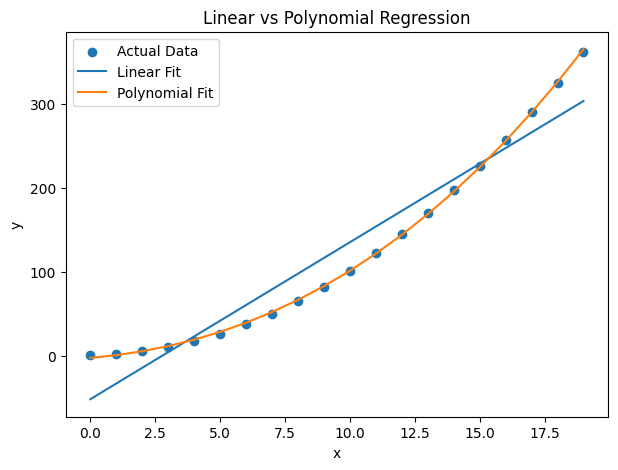

In [25]:
plt.figure(figsize=(7,5))
plt.scatter(x_train, y_train, label="Actual Data")
plt.plot(x_train, y_pred_lin, label="Linear Fit")
plt.plot(x_train, y_pred_poly, label="Polynomial Fit")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Linear vs Polynomial Regression")
plt.legend()
plt.show()

## 8. Learning Curves

The learning curve shows how the cost decreases
during gradient descent.

learning curve는 gradient descent 동안
cost가 어떻게 감소하는지 보여준다.

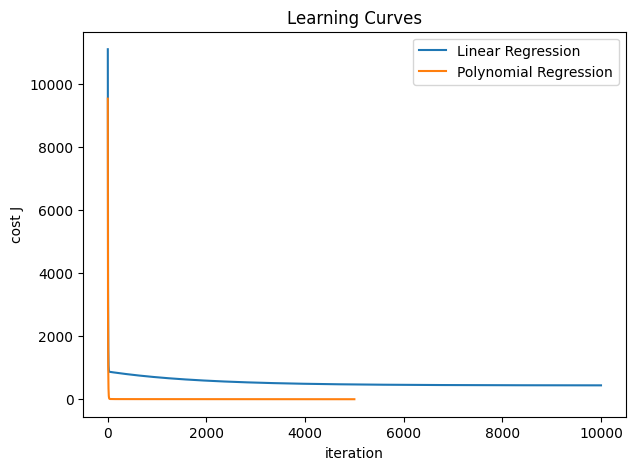

In [26]:
plt.figure(figsize=(7,5))
plt.plot(J_lin, label="Linear Regression")
plt.plot(J_poly, label="Polynomial Regression")
plt.xlabel("iteration")
plt.ylabel("cost J")
plt.title("Learning Curves")
plt.legend()
plt.show()

## Conclusion

Polynomial regression allows linear regression
to fit non-linear data by creating new features.

Polynomial regression은 새로운 feature를 생성함으로써
선형 회귀가 비선형 데이터를 학습할 수 있게 한다.

Feature engineering plays a critical role
in improving model performance.

Feature engineering은 모델 성능을 개선하는 데
중요한 역할을 한다.

Feature scaling becomes more important
when polynomial features are used.

Polynomial feature를 사용할 때는
feature scaling이 더욱 중요하다.